In this project, I'll analyze Lichess Games data from kaggle

In [1]:
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
print("Setup Complete")

Setup Complete


In [2]:
games_data = pd.read_csv('./input/games.csv', index_col='id')

In [3]:
games_data.head()

,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
id,,,,,,,,,,,,,,,
TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [4]:
games_data.describe()

,created_at,last_move_at,turns,white_rating,black_rating,opening_ply
count,2.005800e+04,2.005800e+04,20058.000000,20058.000000,20058.000000,20058.000000
mean,1.483617e+12,1.483618e+12,60.465999,1596.631868,1588.831987,4.816981
std,2.850151e+10,2.850140e+10,33.570585,291.253376,291.036126,2.797152
min,1.376772e+12,1.376772e+12,1.000000,784.000000,789.000000,1.000000
25%,1.477548e+12,1.477548e+12,37.000000,1398.000000,1391.000000,3.000000
50%,1.496010e+12,1.496010e+12,55.000000,1567.000000,1562.000000,4.000000
75%,1.503170e+12,1.503170e+12,79.000000,1793.000000,1784.000000,6.000000
max,1.504493e+12,1.504494e+12,349.000000,2700.000000,2723.000000,28.000000


In [5]:
games_data.columns

Index(['rated', 'created_at', 'last_move_at', 'turns', 'victory_status',
       'winner', 'increment_code', 'white_id', 'white_rating', 'black_id',
       'black_rating', 'moves', 'opening_eco', 'opening_name', 'opening_ply'],
      dtype='str')

In [6]:
games_data['created_at'] = pd.to_datetime(games_data['created_at'], unit='ms')

In [7]:
games_data['last_move_at'] = pd.to_datetime(games_data['last_move_at'], unit='ms')

In [8]:
games_data.isnull().sum()

rated             0
created_at        0
last_move_at      0
turns             0
victory_status    0
winner            0
increment_code    0
white_id          0
white_rating      0
black_id          0
black_rating      0
moves             0
opening_eco       0
opening_name      0
opening_ply       0
dtype: int64

There are no null values in the dataset

In [9]:
games_data = games_data.drop(columns=['created_at', 'last_move_at'])

In [10]:
games_data['winner'].value_counts(normalize=True)#normalize tells percentage

winner
white    0.498604
black    0.454033
draw     0.047363
Name: proportion, dtype: float64

In [11]:
games_data['opening_name'].value_counts().head(10)

opening_name
Van't Kruijs Opening                             368
Sicilian Defense                                 358
Sicilian Defense: Bowdler Attack                 296
French Defense: Knight Variation                 271
Scotch Game                                      271
Scandinavian Defense: Mieses-Kotroc Variation    259
Queen's Pawn Game: Mason Attack                  232
Queen's Pawn Game: Chigorin Variation            229
Scandinavian Defense                             223
Horwitz Defense                                  209
Name: count, dtype: int64

The most popular openings are Van't Kruijs Opening and the Sicilian Defense

In [12]:
games_data['opening_name'].unique()

<StringArray>
[                                    'Slav Defense: Exchange Variation',
                               'Nimzowitsch Defense: Kennedy Variation',
                                'King's Pawn Game: Leonardis Variation',
                               'Queen's Pawn Game: Zukertort Variation',
                                                     'Philidor Defense',
                                 'Sicilian Defense: Mongoose Variation',
                           'Blackmar-Diemer Gambit: Pietrowsky Defense',
    'Nimzowitsch Defense: Kennedy Variation |  Linksspringer Variation',
                                'Italian Game: Schilling-Kostic Gambit',
                        'Scandinavian Defense: Mieses-Kotroc Variation',
 ...
               'Queen's Gambit Refused: Baltic Defense |  Queen Attack',
          'King's Indian Defense: Orthodox Variation |  Bayonet Attack',
              'King's Gambit |  Falkbeer Countergambit |  Miles Gambit',
                                

There are 1477 unique opening played in this dataset

In [13]:
games_data['rating_difference'] = games_data['white_rating'] - games_data['black_rating']

In [14]:
games_data.head()

,rated,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply,rating_difference
id,,,,,,,,,,,,,,
TZJHLljE,False,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5,309
l1NXvwaE,True,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4,61
mIICvQHh,True,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3,-4
kWKvrqYL,True,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3,-15
9tXo1AUZ,True,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5,54


In [15]:
games_data.groupby('winner')['rating_difference'].mean()

winner
black   -88.981113
draw     14.348421
white    95.307469
Name: rating_difference, dtype: float64

When white wins, their average elo rating is 95 points above black's. And when black wins, their average rating is 88 points above whties. When it is a draw, they are usually at around the same level. 

Doing an analysis on which opening(top 50) leads to more wins for white and black

In [16]:
top_openings = games_data['opening_name'].value_counts().head(50)
top_openings

opening_name
Van't Kruijs Opening                             368
Sicilian Defense                                 358
Sicilian Defense: Bowdler Attack                 296
French Defense: Knight Variation                 271
Scotch Game                                      271
Scandinavian Defense: Mieses-Kotroc Variation    259
Queen's Pawn Game: Mason Attack                  232
Queen's Pawn Game: Chigorin Variation            229
Scandinavian Defense                             223
Horwitz Defense                                  209
Caro-Kann Defense                                199
Philidor Defense #3                              198
Philidor Defense #2                              193
Indian Game                                      181
Italian Game: Anti-Fried Liver Defense           180
Four Knights Game: Italian Variation             176
Modern Defense                                   174
Owen Defense                                     168
King's Pawn Game: Wayward Queen A

In [17]:
opening_data = games_data[['opening_name','winner']][games_data['opening_name'].isin(top_openings.index)]
opening_data

,opening_name,winner
id,,
mIICvQHh,King's Pawn Game: Leonardis Variation,white
kWKvrqYL,Queen's Pawn Game: Zukertort Variation,white
9tXo1AUZ,Philidor Defense,white
afoMwnLg,Scandinavian Defense: Mieses-Kotroc Variation,white
HgKLWPsz,Van't Kruijs Opening,white
...,...,...
nYOvevdh,English Opening: King's English Variation,white
uMzb0TPC,French Defense: Knight Variation,black
WSJDhbPl,Queen's Pawn,black


Using unstack() to calculate opening rates from opening data

In [18]:
opening_rates = opening_data.groupby('opening_name')['winner'].value_counts(normalize=True).unstack()
opening_rates

winner,black,draw,white
opening_name,,,
Bird Opening,0.558442,0.051948,0.389610
Bishop's Opening,0.398438,0.062500,0.539062
Bishop's Opening: Berlin Defense,0.329787,0.031915,0.638298
Caro-Kann Defense,0.417085,0.035176,0.547739
English Opening: King's English Variation,0.397959,0.030612,0.571429
Four Knights Game: Italian Variation,0.420455,0.039773,0.539773
French Defense #2,0.500000,0.047170,0.452830
French Defense: Exchange Variation,0.385321,0.082569,0.532110
French Defense: Knight Variation,0.446494,0.055351,0.498155


Getting best opening for white and black

In [19]:
best_opening_for_white = opening_rates.index[opening_rates['white'] == opening_rates['white'].max()]
best_opening_for_white

Index(['King's Knight Opening'], dtype='str', name='opening_name')

In [20]:
best_opening_for_black = opening_rates.index[opening_rates['black'] == opening_rates['black'].max()]
best_opening_for_black

Index(['Van't Kruijs Opening'], dtype='str', name='opening_name')

The best opening for white is King's Knight Opening and for black is Van't Kruijs Opening

<Axes: xlabel='winner', ylabel='percent'>

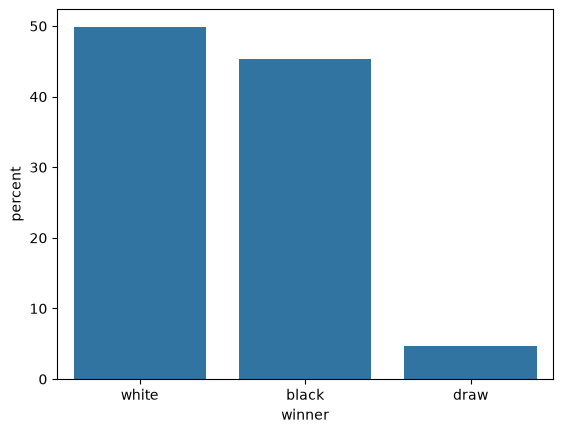

In [78]:
sns.countplot(x = games_data.winner,stat='percent')

<Axes: xlabel='rating_difference', ylabel='Count'>

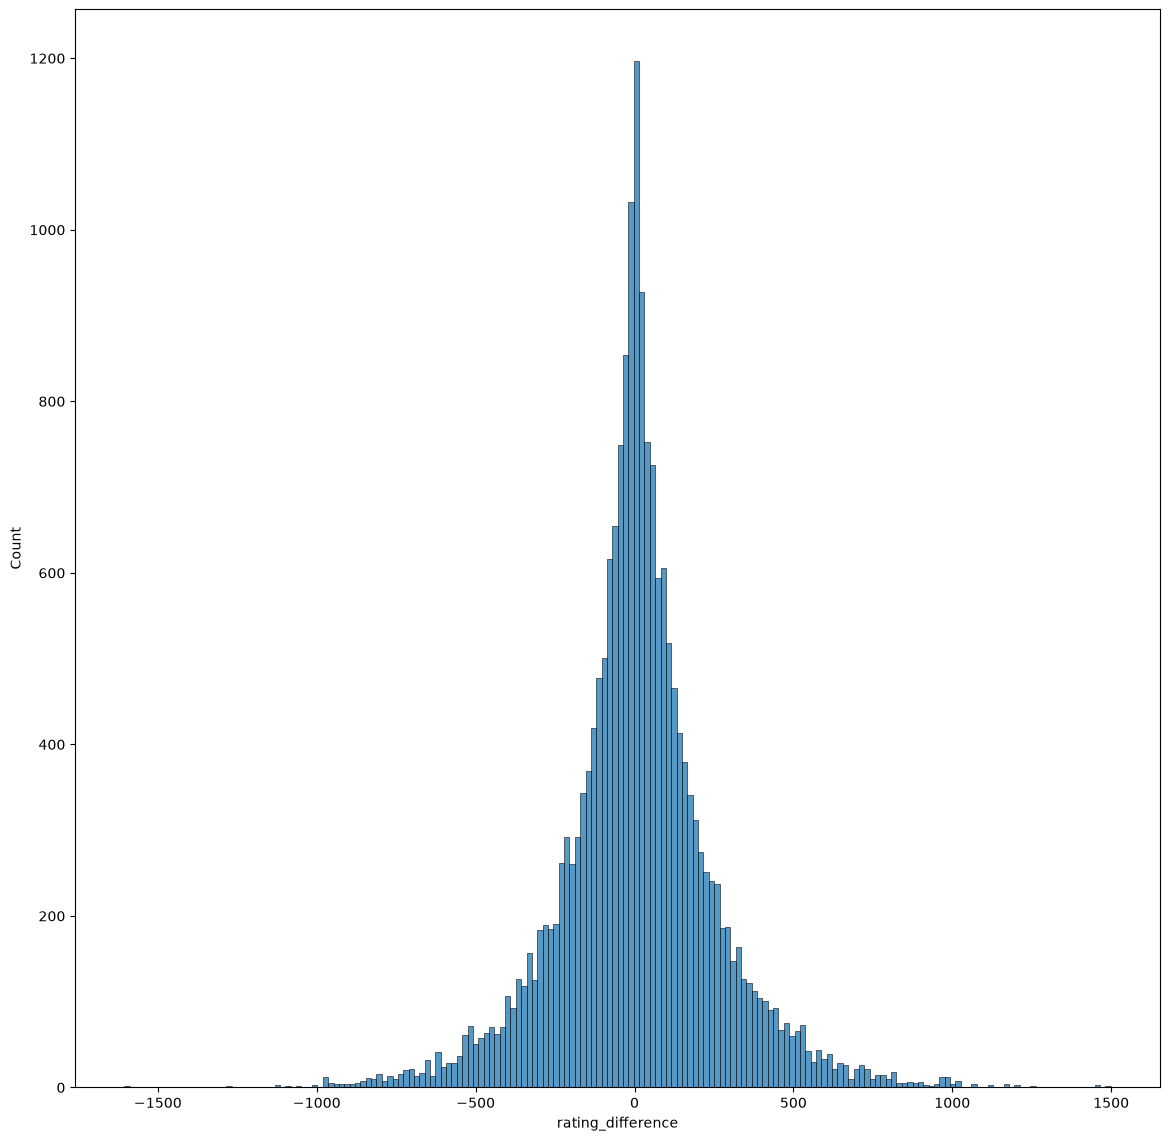

In [52]:
plt.figure(figsize=(14,14))
sns.histplot(x = games_data['rating_difference'])

Most rating difference is 100 points off, i.e., the games are usually between players of not much rating difference 

<Axes: xlabel='white', ylabel='opening_name'>

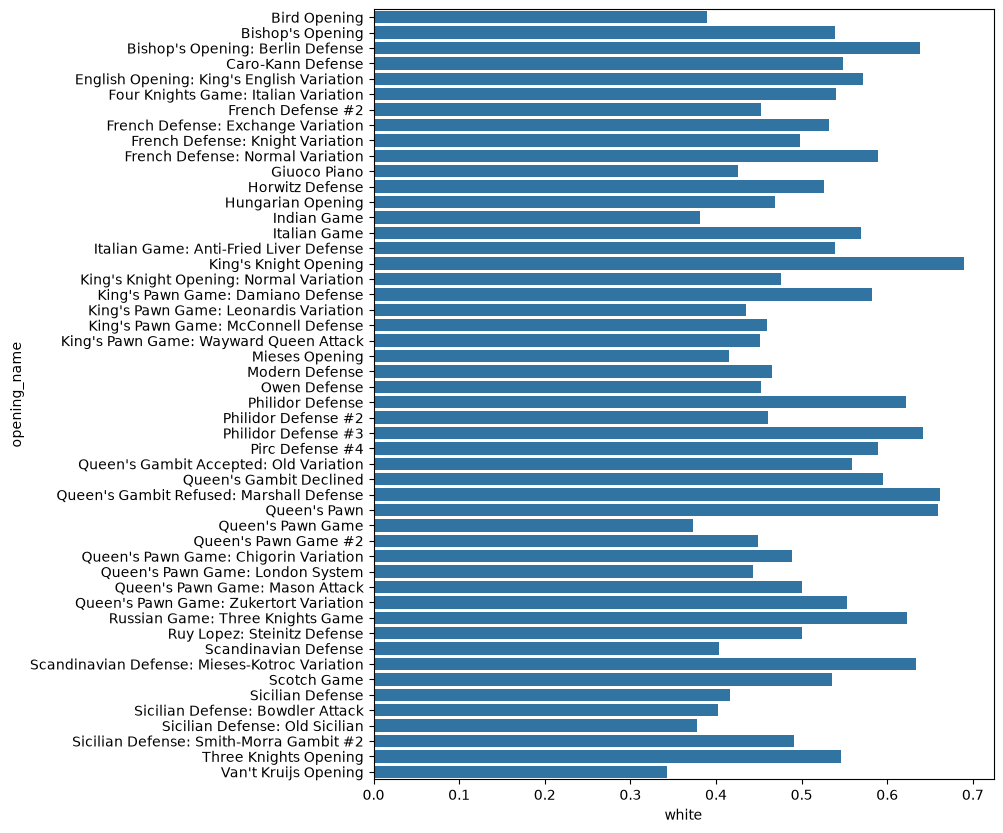

In [79]:
fig, ax = plt.subplots(figsize=(8, 10))
sns.barplot(y = opening_rates.index, x = opening_rates['white'], ax=ax)

<Axes: xlabel='black', ylabel='opening_name'>

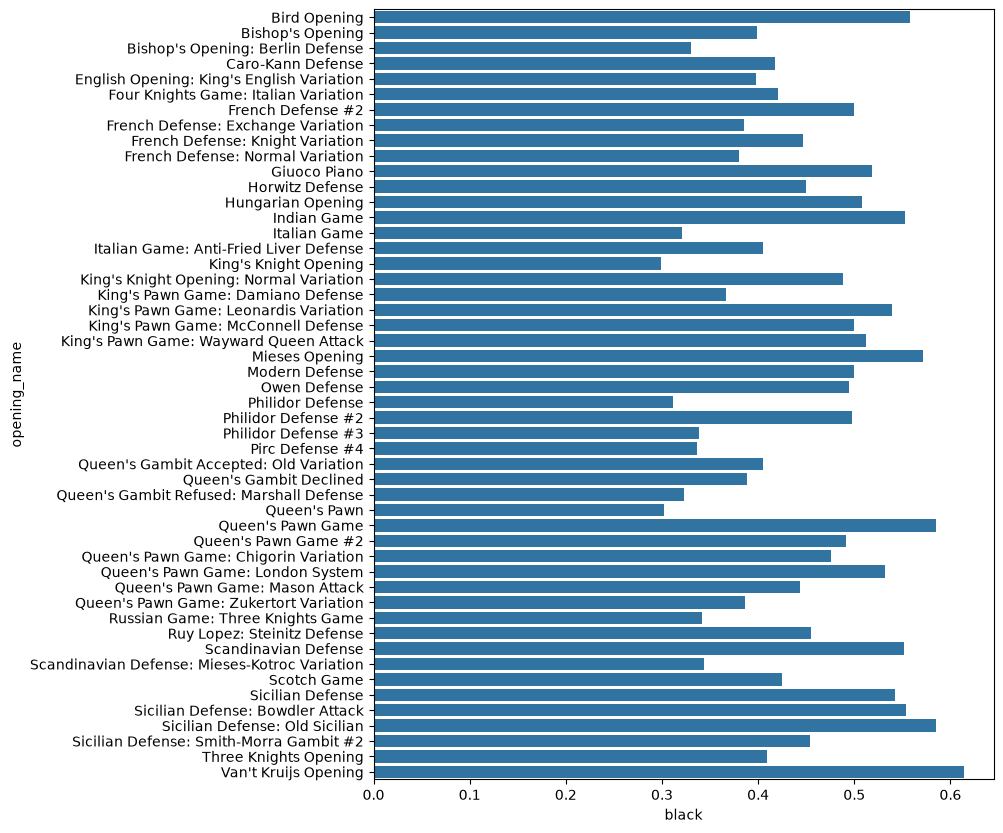

In [72]:
fig, ax = plt.subplots(figsize=(8, 10))
sns.barplot(y = opening_rates.index, x = opening_rates['black'], ax=ax)

<Axes: xlabel='winner', ylabel='rating_difference'>

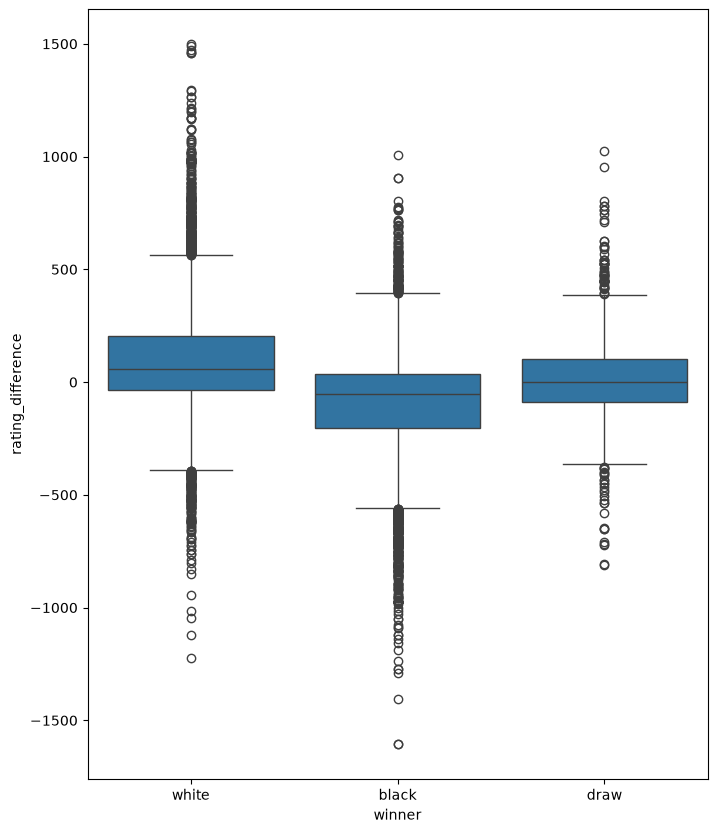

In [74]:
fig, ax = plt.subplots(figsize=(8, 10))
sns.boxplot(data=games_data, x = 'winner', y = 'rating_difference', ax=ax)

In [ ]:

games_data['average_rating'] = (games_data['white_rating'] + games_data['black_rating'])/2

In [82]:
games_data.head()

,rated,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply,rating_difference,average_rating
id,,,,,,,,,,,,,,,
TZJHLljE,False,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5,309,1345.5
l1NXvwaE,True,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4,61,1291.5
mIICvQHh,True,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3,-4,1498.0
kWKvrqYL,True,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3,-15,1446.5
9tXo1AUZ,True,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5,54,1496.0


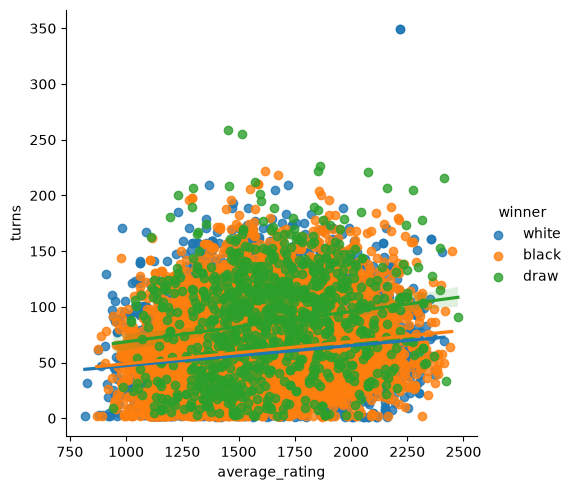

In [87]:
sns.lmplot(x = 'average_rating', y = 'turns', hue = 'winner', data=games_data)

No of turns increase as ratings increase but there's not much difference. Although this plot does show that games which end in a draw have more turns compared to when black or white wins

2. Now that the analysis is done. I will start to predict if rating_difference truly makes a difference. The prediction will then be compared with the actual winner to see the accuracy(ps.. this is a dumb prediction, not an accurate one rn)